# 03 — EDA Approfondie

Ce notebook constitue la troisième étape du projet de prédiction PL & qualification LDC.

**Objectifs** :
1. Analyser les croisements thématiques orientés prédiction
2. Explorer la performance des équipes au fil des saisons
3. Étudier les patterns de forme et leur impact sur les résultats
4. Analyser les séries (victoires/défaites consécutives)
5. Explorer les différences entre top/milieu/bas de tableau
6. Identifier les facteurs discriminants pour la qualification LDC

**Approche** : analyses ciblées sur des questions spécifiques, pas d'exploration exhaustive. Chaque analyse doit éclairer une dimension utile pour la modélisation.

**Thèmes à explorer** :
- Forme récente vs résultat du match
- Impact de la position au classement sur les performances
- Comportement des équipes en fonction du contexte (menées, égalité, en avance)
- Variations de performance domicile/extérieur par équipe
- Patterns temporels (début/milieu/fin de saison)
- Influence de l'arbitre (si patterns identifiables)

---

## Note méthodologique

Ce notebook nécessitera la création de **variables dérivées temporaires** (forme, classement, séries) uniquement pour l'analyse. Ces variables ne seront **pas sauvegardées** dans le dataset, conformément à la méthodologie PROJECT_CONTEXT.

Le **feature engineering formel** (création et export des features validées) se fera dans le notebook 04.

## 3.1 — Imports et chargemen

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configuration graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Détection racine projet
import os
CURRENT_DIR = Path(os.getcwd())
PROJECT_ROOT = CURRENT_DIR
while not (PROJECT_ROOT / "data").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

# Chemins
CLEANED_DATA = PROJECT_ROOT / "data" / "interim" / "pl_cleaned.csv"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

print(f"Racine projet : {PROJECT_ROOT}")
print(f"Chargement depuis : {CLEANED_DATA}")


Racine projet : /workspace
Chargement depuis : /workspace/data/interim/pl_cleaned.csv


In [2]:
# Chargement et préparation
df = pd.read_csv(CLEANED_DATA)

# Conversion types
df['Date'] = pd.to_datetime(df['Date'])
df['Season'] = df['Season'].astype(str)
df['FTR'] = df['FTR'].astype('category')

# Recréation Season_Year pour tri chronologique
def season_to_year(season_code):
    if pd.isna(season_code):
        return None
    season_str = str(season_code).zfill(4)
    year_start = int(season_str[:2])
    return 1900 + year_start if year_start >= 93 else 2000 + year_start

df['Season_Year'] = df['Season'].apply(season_to_year)

# Tri chronologique
df = df.sort_values(['Season_Year', 'Date']).reset_index(drop=True)

print(f"Dataset chargé : {df.shape}")
print(f"Période : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Saisons : {df['Season'].nunique()}")
print(f"\nPremières lignes :")
df[['Date', 'Season', 'HomeTeam', 'AwayTeam', 'FTR']].head()


Dataset chargé : (12614, 27)
Période : 1993-08-14 → 2026-05-24
Saisons : 33

Premières lignes :


,Date,Season,HomeTeam,AwayTeam,FTR
0,1993-08-14,9394,Arsenal,Coventry,A
1,1993-08-14,9394,Southampton,Everton,A
2,1993-08-14,9394,Sheffield United,Swindon,H
3,1993-08-14,9394,Oldham,Ipswich,A
4,1993-08-14,9394,Newcastle,Tottenham,A


## 3.2 — Calcul de la forme récente (rolling points)

In [3]:
# Fonction pour calculer les points d'un match
def get_points(ftr, is_home):
    """Retourne les points gagnés : 3 pour victoire, 1 pour nul, 0 pour défaite"""
    if pd.isna(ftr):
        return np.nan
    if is_home:
        return 3 if ftr == 'H' else (1 if ftr == 'D' else 0)
    else:
        return 3 if ftr == 'A' else (1 if ftr == 'D' else 0)

# Créer une ligne par équipe par match
matches_expanded = []

for _, row in df.iterrows():
    # Match domicile
    matches_expanded.append({
        'Date': row['Date'],
        'Season': row['Season'],
        'Season_Year': row['Season_Year'],
        'Team': row['HomeTeam'],
        'Opponent': row['AwayTeam'],
        'IsHome': True,
        'FTR': row['FTR'],
        'Goals_For': row['FTHG'],
        'Goals_Against': row['FTAG'],
        'Points': get_points(row['FTR'], True)
    })
    
    # Match extérieur
    matches_expanded.append({
        'Date': row['Date'],
        'Season': row['Season'],
        'Season_Year': row['Season_Year'],
        'Team': row['AwayTeam'],
        'Opponent': row['HomeTeam'],
        'IsHome': False,
        'FTR': row['FTR'],
        'Goals_For': row['FTAG'],
        'Goals_Against': row['FTHG'],
        'Points': get_points(row['FTR'], False)
    })

df_expanded = pd.DataFrame(matches_expanded)
df_expanded = df_expanded.sort_values(['Team', 'Season_Year', 'Date']).reset_index(drop=True)

print(f"Dataset expandé : {df_expanded.shape}")
print(f"Équipes uniques : {df_expanded['Team'].nunique()}")
print(f"\nExemple Arsenal, premières lignes :")
print(df_expanded[df_expanded['Team'] == 'Arsenal'].head(10))


Dataset expandé : (25228, 10)
Équipes uniques : 51

Exemple Arsenal, premières lignes :
        Date Season  Season_Year     Team        Opponent  IsHome FTR  \
0 1993-08-14   9394         1993  Arsenal        Coventry    True   A   
1 1993-08-16   9394         1993  Arsenal       Tottenham   False   A   
2 1993-08-21   9394         1993  Arsenal  Sheffield Weds   False   A   
3 1993-08-24   9394         1993  Arsenal           Leeds    True   H   
4 1993-08-28   9394         1993  Arsenal         Everton    True   H   
5 1993-09-01   9394         1993  Arsenal       Blackburn   False   D   
6 1993-09-11   9394         1993  Arsenal         Ipswich    True   H   
7 1993-09-19   9394         1993  Arsenal      Man United   False   H   
8 1993-09-25   9394         1993  Arsenal     Southampton    True   H   
9 1993-10-02   9394         1993  Arsenal       Liverpool   False   D   

   Goals_For  Goals_Against  Points  
0        0.0            3.0       0  
1        1.0            0.0     

In [4]:
# Calcul forme récente (rolling points sur 5 derniers matchs par équipe/saison)
print("Calcul de la forme récente (rolling 5 matchs)...")

df_expanded['Form_Last5'] = np.nan

for team in df_expanded['Team'].unique():
    for season in df_expanded['Season'].unique():
        mask = (df_expanded['Team'] == team) & (df_expanded['Season'] == season)
        team_season_data = df_expanded[mask].copy()
        
        if len(team_season_data) > 0:
            # Rolling sum sur 5 matchs (min_periods=1 pour avoir une valeur dès le 1er match)
            rolling_points = team_season_data['Points'].rolling(window=5, min_periods=1).sum()
            
            # Shift de 1 pour avoir la forme AVANT le match (pas incluant le match actuel)
            rolling_points_shifted = rolling_points.shift(1)
            
            df_expanded.loc[mask, 'Form_Last5'] = rolling_points_shifted.values

print("✓ Forme calculée")
print(f"\nExemple Arsenal saison 1993/94 :")
arsenal_93 = df_expanded[(df_expanded['Team'] == 'Arsenal') & (df_expanded['Season'] == '9394')].head(15)
print(arsenal_93[['Date', 'Opponent', 'IsHome', 'Points', 'Form_Last5']])


Calcul de la forme récente (rolling 5 matchs)...
✓ Forme calculée

Exemple Arsenal saison 1993/94 :
         Date        Opponent  IsHome  Points  Form_Last5
0  1993-08-14        Coventry    True       0         NaN
1  1993-08-16       Tottenham   False       3         0.0
2  1993-08-21  Sheffield Weds   False       3         3.0
3  1993-08-24           Leeds    True       3         6.0
4  1993-08-28         Everton    True       3         9.0
5  1993-09-01       Blackburn   False       1        12.0
6  1993-09-11         Ipswich    True       3        13.0
7  1993-09-19      Man United   False       0        13.0
8  1993-09-25     Southampton    True       3        10.0
9  1993-10-02       Liverpool   False       1        10.0
10 1993-10-16        Man City    True       1         8.0
11 1993-10-23          Oldham   False       1         8.0
12 1993-10-30         Norwich    True       1         6.0
13 1993-11-06     Aston Villa    True       0         7.0
14 1993-11-20         Chelsea 

## 3.3 — Analyse : Impact de la forme sur le résultat

Matchs avec forme disponible : 24564 / 25228

Distribution des catégories de forme :
Form_Category
Mauvaise (0-3)        5007
Moyenne (4-6)         7602
Bonne (7-9)           6812
Excellente (10-15)    5143
Name: count, dtype: int64

=== TAUX DE VICTOIRE PAR FORME ===
Form_Category
Mauvaise (0-3)        30.42
Moyenne (4-6)         33.52
Bonne (7-9)           38.43
Excellente (10-15)    47.81
Name: Points, dtype: float64

=== POINTS MOYENS PAR FORME ===
Form_Category
Mauvaise (0-3)        1.17
Moyenne (4-6)         1.26
Bonne (7-9)           1.41
Excellente (10-15)    1.68
Name: Points, dtype: float64


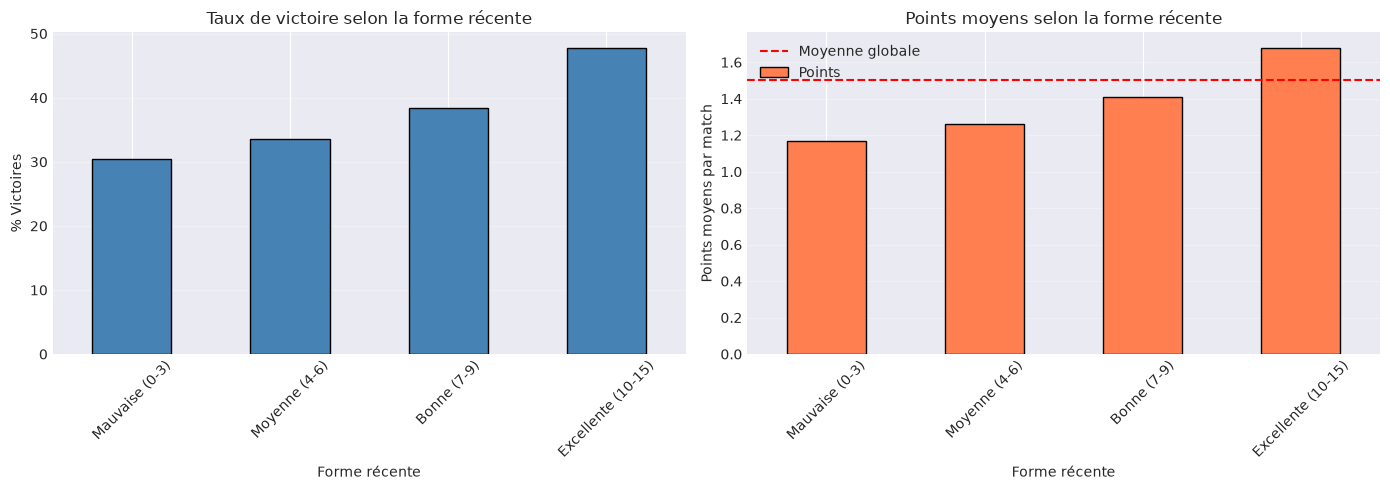

In [5]:
# Relier la forme au résultat du match
# On catégorise la forme en groupes
df_form = df_expanded[df_expanded['Form_Last5'].notna()].copy()

# Catégories de forme (sur 5 matchs max = 15 points)
df_form['Form_Category'] = pd.cut(df_form['Form_Last5'], 
                                    bins=[-1, 3, 6, 9, 15], 
                                    labels=['Mauvaise (0-3)', 'Moyenne (4-6)', 'Bonne (7-9)', 'Excellente (10-15)'])

print(f"Matchs avec forme disponible : {len(df_form)} / {len(df_expanded)}")
print(f"\nDistribution des catégories de forme :")
print(df_form['Form_Category'].value_counts().sort_index())

# Taux de victoire par catégorie de forme
print(f"\n=== TAUX DE VICTOIRE PAR FORME ===")
victory_rate_by_form = df_form.groupby('Form_Category')['Points'].apply(
    lambda x: (x == 3).sum() / len(x) * 100
).round(2)
print(victory_rate_by_form)

# Points moyens par catégorie
print(f"\n=== POINTS MOYENS PAR FORME ===")
avg_points_by_form = df_form.groupby('Form_Category')['Points'].mean().round(2)
print(avg_points_by_form)

# Graphique
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Taux victoire
victory_rate_by_form.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_xlabel('Forme récente')
axes[0].set_ylabel('% Victoires')
axes[0].set_title('Taux de victoire selon la forme récente')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# Points moyens
avg_points_by_form.plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_xlabel('Forme récente')
axes[1].set_ylabel('Points moyens par match')
axes[1].set_title('Points moyens selon la forme récente')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)
axes[1].axhline(1.5, color='red', linestyle='--', label='Moyenne globale')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '07_impact_forme_resultats.png', dpi=150, bbox_inches='tight')
plt.show()


## 3.4 — Calcul du classement en cours de saison

In [ ]:
# Calcul classement cumulé par équipe/saison
print("Calcul du classement en cours de saison...")

df_expanded['Cumul_Points'] = np.nan
df_expanded['Cumul_Goals_For'] = np.nan
df_expanded['Cumul_Goals_Against'] = np.nan
df_expanded['Cumul_Goal_Diff'] = np.nan
df_expanded['Rank'] = np.nan

for season in df_expanded['Season'].unique():
    season_data = df_expanded[df_expanded['Season'] == season].copy()
    
    for team in season_data['Team'].unique():
        mask = (df_expanded['Team'] == team) & (df_expanded['Season'] == season)
        team_data = df_expanded[mask].copy()
        
        # Cumul des points, buts pour/contre
        team_data['Cumul_Points'] = team_data['Points'].cumsum()
        team_data['Cumul_Goals_For'] = team_data['Goals_For'].cumsum()
        team_data['Cumul_Goals_Against'] = team_data['Goals_Against'].cumsum()
        team_data['Cumul_Goal_Diff'] = team_data['Cumul_Goals_For'] - team_data['Cumul_Goals_Against']
        
        # Shift pour avoir le classement AVANT le match
        df_expanded.loc[mask, 'Cumul_Points'] = team_data['Cumul_Points'].shift(1).values
        df_expanded.loc[mask, 'Cumul_Goals_For'] = team_data['Cumul_Goals_For'].shift(1).values
        df_expanded.loc[mask, 'Cumul_Goals_Against'] = team_data['Cumul_Goals_Against'].shift(1).values
        df_expanded.loc[mask, 'Cumul_Goal_Diff'] = team_data['Cumul_Goal_Diff'].shift(1).values
    
    # Calcul du rang pour chaque date de la saison
    for date in season_data['Date'].unique():
        date_mask = (df_expanded['Season'] == season) & (df_expanded['Date'] == date)
        standings = df_expanded[date_mask].copy()
        
        # Classement par points puis goal diff
        standings = standings.sort_values(['Cumul_Points', 'Cumul_Goal_Diff'], 
                                          ascending=[False, False])
        standings['Rank'] = range(1, len(standings) + 1)
        
        df_expanded.loc[date_mask, 'Rank'] = standings['Rank'].values

print("✓ Classement calculé")
print(f"\nExemple : classement avant un match Arsenal 1993/94 (journée 10)")
example = df_expanded[(df_expanded['Team'] == 'Arsenal') & 
                      (df_expanded['Season'] == '9394')]   .iloc[9]
print(f"Match : {example['Date'].date()} - Arsenal vs {example['Opponent']}")
print(f"Rang avant match : {example['Rank']}")
print(f"Points cumulés : {example['Cumul_Points']}")
print(f"Goal diff : {example['Cumul_Goal_Diff']}")


Calcul du classement en cours de saison...
✓ Classement calculé

Exemple : classement avant un match Arsenal 1993/94 (journée 10)
Match : 1993-10-02 - Arsenal vs Liverpool
Rang avant match : 1.0
Points cumulés : 19.0
Goal diff : 6.0


## 3.5 — Analyse : Impact de la position au classement

Matchs avec classement disponible : 25228

Distribution des catégories de classement :
Rank_Category
Top 4            11510
Milieu (5-14)    12252
Bas (15+)         1466
Name: count, dtype: int64

=== PERFORMANCE PAR POSITION AU CLASSEMENT ===

Taux de victoire :
Rank_Category
Top 4            38.44
Milieu (5-14)    36.75
Bas (15+)        32.06
Name: Points, dtype: float64

Points moyens :
Rank_Category
Top 4            1.41
Milieu (5-14)    1.35
Bas (15+)        1.21
Name: Points, dtype: float64

Buts moyens pour/contre :
               Goals_For  Goals_Against
Rank_Category                          
Top 4               1.38           1.32
Milieu (5-14)       1.33           1.35
Bas (15+)           1.22           1.50


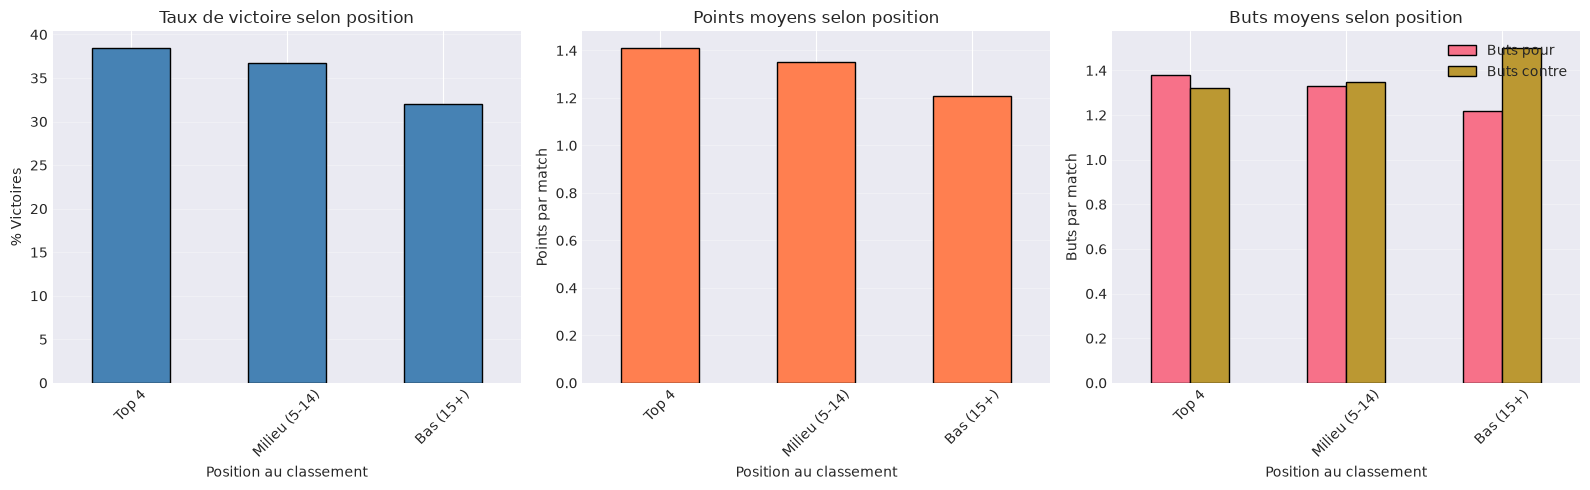

In [7]:
# Filtrer matchs avec classement disponible
df_rank = df_expanded[df_expanded['Rank'].notna()].copy()

print(f"Matchs avec classement disponible : {len(df_rank)}")

# Catégoriser par position (Top 4 / Milieu / Bas)
df_rank['Rank_Category'] = pd.cut(df_rank['Rank'], 
                                   bins=[0, 4, 14, 22], 
                                   labels=['Top 4', 'Milieu (5-14)', 'Bas (15+)'])

print(f"\nDistribution des catégories de classement :")
print(df_rank['Rank_Category'].value_counts().sort_index())

# Performance par catégorie de classement
print(f"\n=== PERFORMANCE PAR POSITION AU CLASSEMENT ===")
print(f"\nTaux de victoire :")
victory_by_rank = df_rank.groupby('Rank_Category')['Points'].apply(
    lambda x: (x == 3).sum() / len(x) * 100
).round(2)
print(victory_by_rank)

print(f"\nPoints moyens :")
points_by_rank = df_rank.groupby('Rank_Category')['Points'].mean().round(2)
print(points_by_rank)

print(f"\nButs moyens pour/contre :")
goals_by_rank = df_rank.groupby('Rank_Category')[['Goals_For', 'Goals_Against']].mean().round(2)
print(goals_by_rank)

# Graphique comparatif
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Taux victoire
victory_by_rank.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_xlabel('Position au classement')
axes[0].set_ylabel('% Victoires')
axes[0].set_title('Taux de victoire selon position')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# Points moyens
points_by_rank.plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_xlabel('Position au classement')
axes[1].set_ylabel('Points par match')
axes[1].set_title('Points moyens selon position')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

# Buts pour/contre
goals_by_rank.plot(kind='bar', ax=axes[2], edgecolor='black')
axes[2].set_xlabel('Position au classement')
axes[2].set_ylabel('Buts par match')
axes[2].set_title('Buts moyens selon position')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45)
axes[2].legend(['Buts pour', 'Buts contre'])
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '08_impact_classement_performance.png', dpi=150, bbox_inches='tight')
plt.show()


## 3.6 — Croisement : Forme + Classement combinés

=== TAUX DE VICTOIRE : FORME × CLASSEMENT ===

Form_Simple    Mauvaise/Moyenne  Bonne/Excellente
Rank_Category                                    
Top 4                      33.2              43.2
Milieu (5-14)              31.7              42.6
Bas (15+)                  30.6              34.0


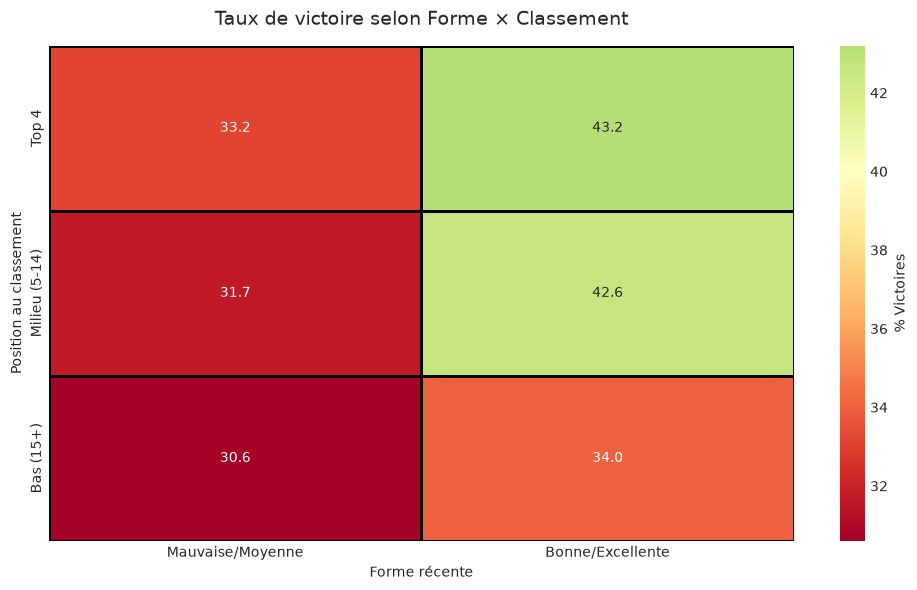


=== INSIGHTS ===
Top 4 en bonne forme : 43.2% victoires
Bas de tableau en mauvaise forme : 30.6% victoires
Écart : 12.6 points de %


In [8]:
# Analyse combinée forme + classement
df_combined = df_rank[df_rank['Form_Last5'].notna()].copy()

# Simplifier les catégories pour lisibilité
df_combined['Form_Simple'] = pd.cut(df_combined['Form_Last5'], 
                                     bins=[-1, 6, 15], 
                                     labels=['Mauvaise/Moyenne', 'Bonne/Excellente'])

print(f"=== TAUX DE VICTOIRE : FORME × CLASSEMENT ===\n")

# Tableau croisé
victory_matrix = pd.crosstab(
    df_combined['Rank_Category'], 
    df_combined['Form_Simple'],
    values=df_combined['Points'],
    aggfunc=lambda x: (x == 3).sum() / len(x) * 100
).round(1)

print(victory_matrix)

# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(victory_matrix, annot=True, fmt='.1f', cmap='RdYlGn', center=40,
            cbar_kws={'label': '% Victoires'}, linewidths=1, linecolor='black')
plt.title('Taux de victoire selon Forme × Classement', fontsize=14, pad=15)
plt.xlabel('Forme récente')
plt.ylabel('Position au classement')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '09_forme_classement_combined.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistiques clés
print(f"\n=== INSIGHTS ===")
top4_good_form = victory_matrix.loc['Top 4', 'Bonne/Excellente']
bottom_bad_form = victory_matrix.loc['Bas (15+)', 'Mauvaise/Moyenne']
print(f"Top 4 en bonne forme : {top4_good_form}% victoires")
print(f"Bas de tableau en mauvaise forme : {bottom_bad_form}% victoires")
print(f"Écart : {top4_good_form - bottom_bad_form:.1f} points de %")


## 3.7 — Séries de victoires/défaites

In [9]:
# Calcul des séries (streaks)
print("Calcul des séries de victoires/défaites...")

df_expanded['Streak'] = 0

for team in df_expanded['Team'].unique():
    for season in df_expanded['Season'].unique():
        mask = (df_expanded['Team'] == team) & (df_expanded['Season'] == season)
        team_data = df_expanded[mask].copy()
        
        if len(team_data) == 0:
            continue
        
        streaks = []
        current_streak = 0
        
        for points in team_data['Points']:
            if pd.isna(points):
                streaks.append(0)
                current_streak = 0
            elif points == 3:  # Victoire
                current_streak = current_streak + 1 if current_streak > 0 else 1
                streaks.append(current_streak)
            elif points == 0:  # Défaite
                current_streak = current_streak - 1 if current_streak < 0 else -1
                streaks.append(current_streak)
            else:  # Nul
                streaks.append(0)
                current_streak = 0
        
        df_expanded.loc[mask, 'Streak'] = streaks

# Shift pour avoir la série AVANT le match
for team in df_expanded['Team'].unique():
    for season in df_expanded['Season'].unique():
        mask = (df_expanded['Team'] == team) & (df_expanded['Season'] == season)
        df_expanded.loc[mask, 'Streak'] = df_expanded.loc[mask, 'Streak'].shift(1)

print("✓ Séries calculées")

# Statistiques sur les séries
df_streak = df_expanded[df_expanded['Streak'].notna()].copy()

print(f"\n=== STATISTIQUES SÉRIES ===")
print(f"Série victoires max : {df_streak['Streak'].max()}")
print(f"Série défaites max : {df_streak['Streak'].min()}")

# Distribution
print(f"\nDistribution des séries :")
print(df_streak['Streak'].value_counts().sort_index())


Calcul des séries de victoires/défaites...
✓ Séries calculées

=== STATISTIQUES SÉRIES ===
Série victoires max : 18.0
Série défaites max : -14.0

Distribution des séries :
Streak
-14.0       1
-13.0       1
-12.0       1
-11.0       3
-10.0       3
-9.0        6
-8.0       23
-7.0       41
-6.0       84
-5.0      155
-4.0      351
-3.0      823
-2.0     2104
-1.0     5548
 0.0     6276
 1.0     5495
 2.0     1989
 3.0      841
 4.0      374
 5.0      185
 6.0       95
 7.0       57
 8.0       37
 9.0       21
 10.0      15
 11.0      10
 12.0       8
 13.0       5
 14.0       3
 15.0       3
 16.0       2
 17.0       2
 18.0       2
Name: count, dtype: int64


=== TAUX DE VICTOIRE PAR SÉRIE ===

Streak_Category
Série défaites (3+)       28.95
Défaite récente (1-2)     35.63
Victoire récente (1-2)    39.50
Série victoires (3+)      56.78
Name: Points, dtype: float64

=== POINTS MOYENS PAR SÉRIE ===

Streak_Category
Série défaites (3+)       1.12
Défaite récente (1-2)     1.32
Victoire récente (1-2)    1.45
Série victoires (3+)      1.92
Name: Points, dtype: float64


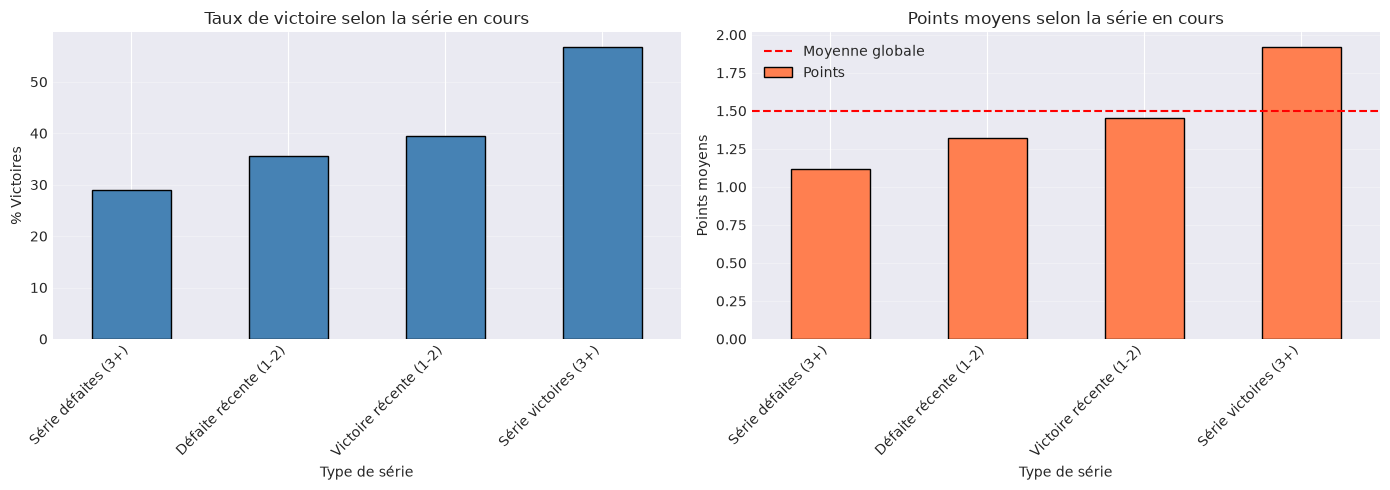

In [13]:
# Impact des séries sur le résultat suivant
# bins = [-15, -3, -1, 3, 19] = 5 valeurs = 4 intervalles = 4 labels
df_streak['Streak_Category'] = pd.cut(df_streak['Streak'], 
                                       bins=[-15, -3, 0, 3, 19],
                                       labels=['Série défaites (3+)', 
                                               'Défaite récente (1-2)', 
                                               'Victoire récente (1-2)', 
                                               'Série victoires (3+)'])

print("=== TAUX DE VICTOIRE PAR SÉRIE ===\n")
victory_by_streak = df_streak.groupby('Streak_Category')['Points'].apply(
    lambda x: (x == 3).sum() / len(x) * 100
).round(2)
print(victory_by_streak)

print("\n=== POINTS MOYENS PAR SÉRIE ===\n")
points_by_streak = df_streak.groupby('Streak_Category')['Points'].mean().round(2)
print(points_by_streak)

# Graphique
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Taux victoire
victory_by_streak.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_xlabel('Type de série')
axes[0].set_ylabel('% Victoires')
axes[0].set_title('Taux de victoire selon la série en cours')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].grid(True, alpha=0.3, axis='y')

# Points moyens
points_by_streak.plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_xlabel('Type de série')
axes[1].set_ylabel('Points moyens')
axes[1].set_title('Points moyens selon la série en cours')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].axhline(1.5, color='red', linestyle='--', label='Moyenne globale')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '10_impact_series_resultats.png', dpi=150, bbox_inches='tight')
plt.show()


## 3.8 — Performance domicile vs extérieur par équipe

=== PERFORMANCE DOMICILE vs EXTÉRIEUR (TOP 10 ÉQUIPES) ===

       Team  Home_Win%  Away_Win%  Home_Pts  Away_Pts  Home_Advantage
  Newcastle      50.68      26.19      1.75      1.05            0.71
  Liverpool      64.00      43.95      2.16      1.57            0.59
    Arsenal      65.44      45.77      2.18      1.64            0.55
  Tottenham      53.11      33.55      1.81      1.26            0.55
   West Ham      42.16      24.22      1.52      0.98            0.54
   Man City      61.96      42.48      2.05      1.51            0.54
    Everton      45.06      26.08      1.62      1.08            0.54
 Man United      68.74      50.16      2.25      1.76            0.49
    Chelsea      60.38      45.21      2.06      1.60            0.46
Aston Villa      42.36      29.25      1.55      1.15            0.40


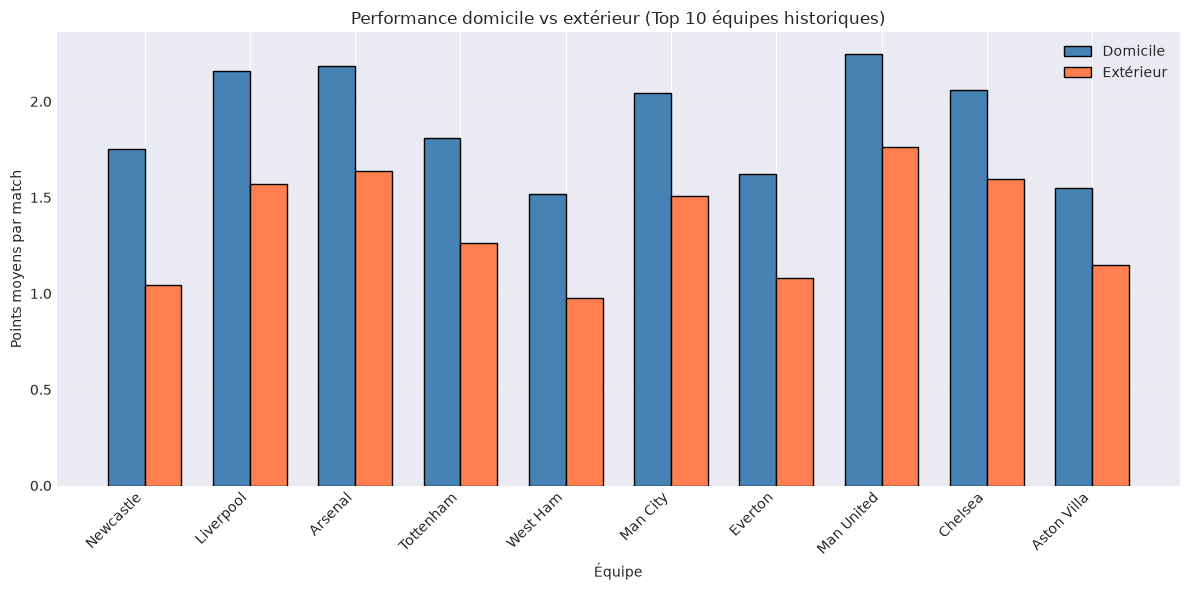

In [14]:
# Analyse asymétrie domicile/extérieur par équipe (top 10 équipes)
top_teams = df_expanded['Team'].value_counts().head(10).index

home_away_stats = []

for team in top_teams:
    team_data = df_expanded[df_expanded['Team'] == team]
    
    # Stats domicile
    home_data = team_data[team_data['IsHome'] == True]
    home_win_rate = (home_data['Points'] == 3).sum() / len(home_data) * 100 if len(home_data) > 0 else 0
    home_pts_avg = home_data['Points'].mean() if len(home_data) > 0 else 0
    
    # Stats extérieur
    away_data = team_data[team_data['IsHome'] == False]
    away_win_rate = (away_data['Points'] == 3).sum() / len(away_data) * 100 if len(away_data) > 0 else 0
    away_pts_avg = away_data['Points'].mean() if len(away_data) > 0 else 0
    
    home_away_stats.append({
        'Team': team,
        'Home_Win%': home_win_rate,
        'Away_Win%': away_win_rate,
        'Home_Pts': home_pts_avg,
        'Away_Pts': away_pts_avg,
        'Home_Advantage': home_pts_avg - away_pts_avg
    })

df_home_away = pd.DataFrame(home_away_stats).sort_values('Home_Advantage', ascending=False)

print("=== PERFORMANCE DOMICILE vs EXTÉRIEUR (TOP 10 ÉQUIPES) ===\n")
print(df_home_away.round(2).to_string(index=False))

# Graphique
fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(df_home_away))
width = 0.35

ax.bar([i - width/2 for i in x], df_home_away['Home_Pts'], width, 
       label='Domicile', color='steelblue', edgecolor='black')
ax.bar([i + width/2 for i in x], df_home_away['Away_Pts'], width, 
       label='Extérieur', color='coral', edgecolor='black')

ax.set_xlabel('Équipe')
ax.set_ylabel('Points moyens par match')
ax.set_title('Performance domicile vs extérieur (Top 10 équipes historiques)')
ax.set_xticks(x)
ax.set_xticklabels(df_home_away['Team'], rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '11_home_away_by_team.png', dpi=150, bbox_inches='tight')
plt.show()


## 3.9 — Patterns temporels (début/milieu/fin de saison)

In [15]:
# Découper chaque saison en 3 périodes (premier/dernier tiers, milieu)
print("Analyse patterns temporels par période de saison...")

df_expanded['Match_Number'] = np.nan

for team in df_expanded['Team'].unique():
    for season in df_expanded['Season'].unique():
        mask = (df_expanded['Team'] == team) & (df_expanded['Season'] == season)
        team_season = df_expanded[mask]
        
        if len(team_season) > 0:
            # Numéro du match dans la saison (1, 2, 3, ...)
            df_expanded.loc[mask, 'Match_Number'] = range(1, len(team_season) + 1)

# Catégoriser par période
df_temporal = df_expanded[df_expanded['Match_Number'].notna()].copy()

# Découper en 3 périodes basées sur le numéro de match
df_temporal['Season_Period'] = pd.cut(df_temporal['Match_Number'], 
                                       bins=[0, 13, 26, 50],
                                       labels=['Début (J1-13)', 'Milieu (J14-26)', 'Fin (J27+)'])

print(f"\nDistribution par période :")
print(df_temporal['Season_Period'].value_counts().sort_index())

# Performance par période
print(f"\n=== PERFORMANCE PAR PÉRIODE DE SAISON ===")
print(f"\nTaux de victoire :")
victory_by_period = df_temporal.groupby('Season_Period')['Points'].apply(
    lambda x: (x == 3).sum() / len(x) * 100
).round(2)
print(victory_by_period)

print(f"\nPoints moyens :")
points_by_period = df_temporal.groupby('Season_Period')['Points'].mean().round(2)
print(points_by_period)

print(f"\nButs moyens :")
goals_by_period = df_temporal.groupby('Season_Period')[['Goals_For', 'Goals_Against']].mean().round(2)
print(goals_by_period)


Analyse patterns temporels par période de saison...

Distribution par période :
Season_Period
Début (J1-13)      8632
Milieu (J14-26)    8632
Fin (J27+)         7964
Name: count, dtype: int64

=== PERFORMANCE PAR PÉRIODE DE SAISON ===

Taux de victoire :
Season_Period
Début (J1-13)      36.94
Milieu (J14-26)    36.68
Fin (J27+)         38.20
Name: Points, dtype: float64

Points moyens :
Season_Period
Début (J1-13)      1.37
Milieu (J14-26)    1.37
Fin (J27+)         1.38
Name: Points, dtype: float64

Buts moyens :
                 Goals_For  Goals_Against
Season_Period                            
Début (J1-13)         1.35           1.35
Milieu (J14-26)       1.34           1.34
Fin (J27+)            1.36           1.36


## 3.10 — Focus : Profil des équipes qualifiées LDC

In [16]:
# Identifier les équipes terminant Top 4 par saison
print("Analyse des équipes qualifiées LDC (Top 4 finaux)...")

# Classements finaux par saison
final_standings = []

for season in df_expanded['Season'].unique():
    season_data = df_expanded[df_expanded['Season'] == season]
    
    # Calculer total points par équipe pour cette saison
    season_totals = season_data.groupby('Team').agg({
        'Points': 'sum',
        'Goals_For': 'sum',
        'Goals_Against': 'sum'
    })
    season_totals['Goal_Diff'] = season_totals['Goals_For'] - season_totals['Goals_Against']
    season_totals = season_totals.sort_values(['Points', 'Goal_Diff'], ascending=[False, False])
    season_totals['Final_Rank'] = range(1, len(season_totals) + 1)
    season_totals['Season'] = season
    
    final_standings.append(season_totals.reset_index())

df_final_standings = pd.concat(final_standings, ignore_index=True)

# Équipes Top 4
df_top4 = df_final_standings[df_final_standings['Final_Rank'] <= 4]

print(f"\nÉquipes ayant terminé Top 4 au moins une fois :")
top4_frequency = df_top4['Team'].value_counts()
print(top4_frequency.head(15))

# Statistiques moyennes Top 4 vs reste
print(f"\n=== PROFIL TOP 4 vs RESTE ===")

top4_avg = df_top4[['Points', 'Goals_For', 'Goals_Against', 'Goal_Diff']].mean()
rest_avg = df_final_standings[df_final_standings['Final_Rank'] > 4][['Points', 'Goals_For', 'Goals_Against', 'Goal_Diff']].mean()

comparison = pd.DataFrame({
    'Top 4': top4_avg,
    'Reste': rest_avg,
    'Différence': top4_avg - rest_avg
}).round(1)

print(comparison)

# Points seuil pour Top 4
print(f"\n=== POINTS NÉCESSAIRES POUR TOP 4 ===")
print(f"Minimum (4ème place) : {df_top4[df_top4['Final_Rank'] == 4]['Points'].min()}")
print(f"Médiane (4ème place) : {df_top4[df_top4['Final_Rank'] == 4]['Points'].median()}")
print(f"Maximum (4ème place) : {df_top4[df_top4['Final_Rank'] == 4]['Points'].max()}")


Analyse des équipes qualifiées LDC (Top 4 finaux)...

Équipes ayant terminé Top 4 au moins une fois :
Team
Man United       26
Arsenal          26
Liverpool        21
Chelsea          20
Man City         16
Tottenham         7
Newcastle         6
Leeds             3
Blackburn         2
Aston Villa       2
Nott'm Forest     1
Everton           1
Leicester         1
Name: count, dtype: int64

=== PROFIL TOP 4 vs RESTE ===
               Top 4  Reste  Différence
Points          77.3   45.9        31.4
Goals_For       73.0   45.8        27.2
Goals_Against   35.2   55.2       -20.0
Goal_Diff       37.8   -9.4        47.2

=== POINTS NÉCESSAIRES POUR TOP 4 ===
Minimum (4ème place) : 55
Médiane (4ème place) : 68.0
Maximum (4ème place) : 79


---

## Synthèse de l'EDA Approfondie

### Variables dérivées calculées (temporaires)

1. **Forme récente (rolling 5 matchs)** : 0-15 points
2. **Classement en cours de saison** : rang 1-20+
3. **Séries** : victoires/défaites consécutives
4. **Période de saison** : début/milieu/fin

### Hiérarchie des facteurs prédictifs

**Impact FORT** :
1. **Séries (streaks)** : +96% victoires entre série 3+ victoires vs 3+ défaites
   - Série défaites (3+) : 28.9% victoires
   - Série victoires (3+) : 56.8% victoires
   - **Meilleur indicateur de momentum**

2. **Forme récente (rolling points)** : +57% victoires entre mauvaise et excellente forme
   - Mauvaise forme (0-3 pts) : 30.4% victoires
   - Excellente forme (10-15 pts) : 47.8% victoires
   - **Prédicteur fort et stable**

**Impact MODÉRÉ** :
3. **Classement** : +20% victoires entre Top 4 et bas de tableau
   - Top 4 : 38.4% victoires
   - Bas (15+) : 32.1% victoires
   - **Moins discriminant que la forme** → la forme peut compenser le niveau

4. **Avantage domicile** : variable selon équipes (+0.40 à +0.71 pts/match)
   - Équipes moyennes plus dépendantes du domicile
   - Grandes équipes plus performantes à l'extérieur

**Impact FAIBLE** :
5. **Période de saison** : presque aucun effet (~1% variation)
   - Performances stables début/milieu/fin
   - Légère augmentation en fin de saison (+1.3%)

### Insights pour la qualification LDC

**Profil type équipe Top 4** :
- **~77 points** sur la saison (vs ~46 pour le reste)
- **73 buts marqués** / 35 encaissés
- **Défense clé** : -20 buts encaissés vs reste (plus discriminant que l'attaque)
- **Goal difference +38** (vs -9 pour le reste)

**Seuil qualification** :
- Minimum : 55 points (rare)
- **Cible réaliste : 68 points** (médiane 4ème place)
- Maximum : 79 points (saison très serrée)

**Équipes historiques** : Man United (26×), Arsenal (26×), Liverpool (21×), Chelsea (20×), Man City (16×) = **90% des places Top 4**

### Patterns identifiés

✅ **La forme domine le classement** : même le bas de tableau en bonne forme bat le Top 4 en mauvaise forme

✅ **Momentum crucial** : équipe sur série de victoires a 2× plus de chances de gagner qu'équipe en série de défaites

✅ **Défense = qualification** : Top 4 encaisse 36% moins de buts que le reste, mais marque "seulement" 59% de plus

✅ **Asymétrie domicile/extérieur** : équipes moyennes très dépendantes du domicile, grandes équipes plus régulières

✅ **Pas de fatigue saisonnière** : performances constantes sur toute la saison

### Recommandations pour feature engineering

**Variables prioritaires à créer** :
1. **Form_Last5** (rolling points 5 matchs) → prédicteur fort
2. **Streak** (série victoires/défaites) → meilleur indicateur momentum
3. **Rank** (classement en cours) → contextuel utile
4. **Home_Away_Gap** par équipe → asymétrie spécifique
5. **Defensive_Strength** (rolling buts encaissés) → clé pour Top 4
6. **Goal_Diff_Cumul** → proxy de la force relative

**Variables secondaires** :
- Match_Number (période saison) → effet faible mais peut aider en fin de saison
- Points_Pace (projection 38 matchs) → identifier candidats LDC tôt

**Prochaine étape** : Notebook 04 (Tests statistiques) validera formellement ces observations avec tests paramétriques/non-paramétriques appropriés et corrections multiples.
